<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HESQForce007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(0, 2*np.pi, N)
omega = 1.0
epsilon = 0.01

# Alternating charge zones
charge = np.where(np.sin(omega * x) > 0, epsilon, -epsilon)
lattice = charge.copy()
history = [lattice.copy()]


In [2]:
# Propagation cell
def evolve_charge(lattice, dt=0.1):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        interaction = lattice[i+1] - 2*lattice[i] + lattice[i-1]
        polarity = np.sign(lattice[i])
        new[i] += dt * interaction * polarity
    return new

for t in range(1000):
    lattice = evolve_charge(lattice)
    if t % 50 == 0:
        history.append(lattice.copy())


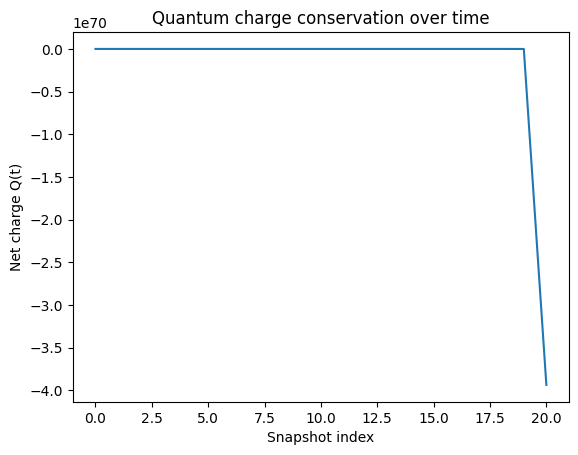

In [3]:
# Net charge over time
net_charge = [np.sum(h) for h in history]

plt.plot(range(len(net_charge)), net_charge)
plt.xlabel("Snapshot index")
plt.ylabel("Net charge Q(t)")
plt.title("Quantum charge conservation over time")
plt.show()


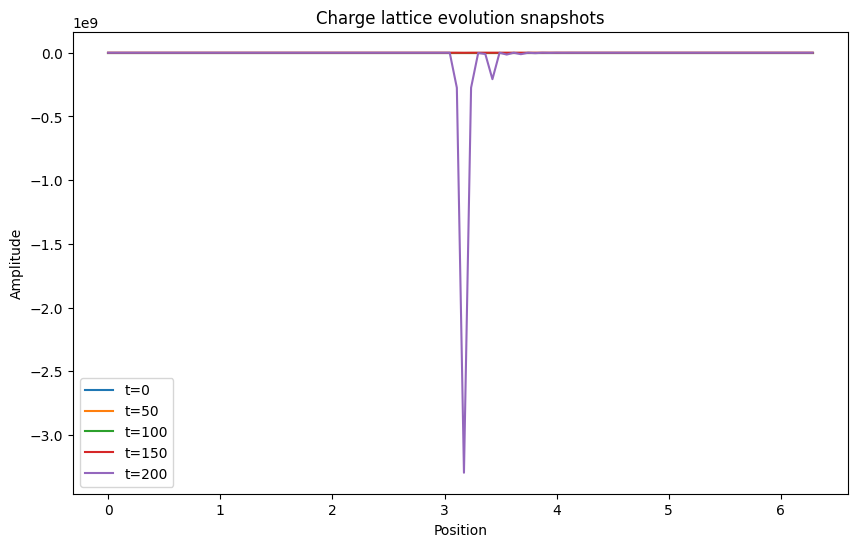

In [4]:
# Lattice snapshots
plt.figure(figsize=(10,6))
for idx, h in enumerate(history[:5]):
    plt.plot(x, h, label=f"t={idx*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Charge lattice evolution snapshots")
plt.legend()
plt.show()
